__LINEAR REGRESSION__

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [37]:
df = pd.read_csv("diabetes_dataset.csv")

In [38]:
X = df.drop(columns=["Diabetes"])
y = df["Diabetes"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [43]:
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.09959307048422868
R^2 Score: 0.37754330947357084


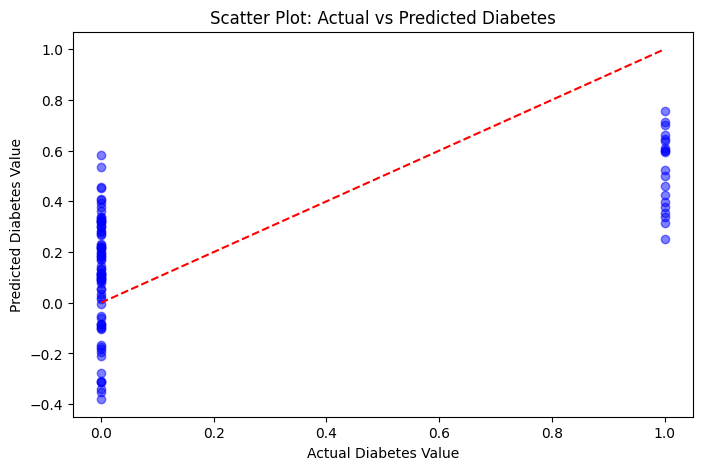

In [44]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([0, 1], [0, 1], '--', color="red")  
plt.xlabel("Actual Diabetes Value")
plt.ylabel("Predicted Diabetes Value")
plt.title("Scatter Plot: Actual vs Predicted Diabetes")
plt.show()

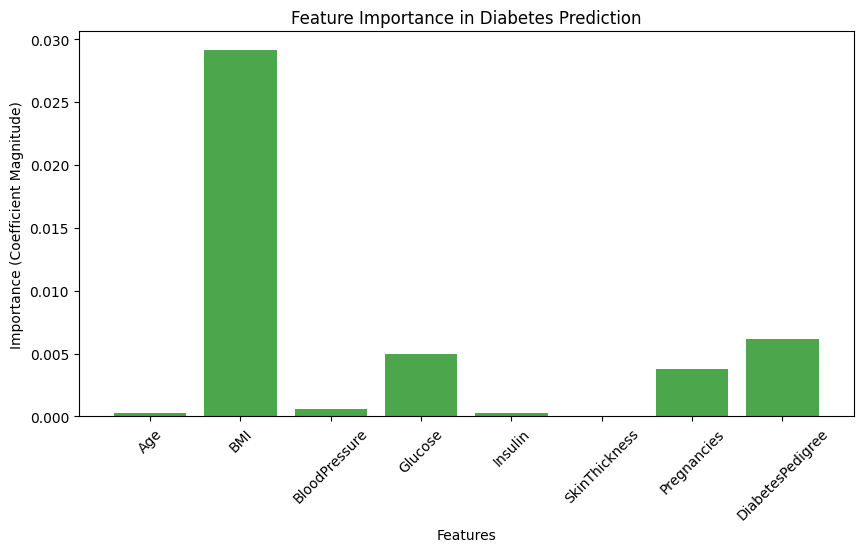

In [45]:
feature_importance = np.abs(model.coef_) 
feature_names = X.columns

plt.figure(figsize=(10, 5))
plt.bar(feature_names, feature_importance, color="green", alpha=0.7)
plt.xlabel("Features")
plt.ylabel("Importance (Coefficient Magnitude)")
plt.title("Feature Importance in Diabetes Prediction")
plt.xticks(rotation=45)
plt.show()


__KNN__

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [47]:
df = pd.read_csv("diabetes_dataset.csv")

In [48]:
X = df.drop(columns=["Diabetes"]) 
y = df["Diabetes"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [52]:
y_pred = knn.predict(X_test_scaled)

In [53]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [54]:
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)

Accuracy: 0.91
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        80
           1       1.00      0.55      0.71        20

    accuracy                           0.91       100
   macro avg       0.95      0.78      0.83       100
weighted avg       0.92      0.91      0.90       100



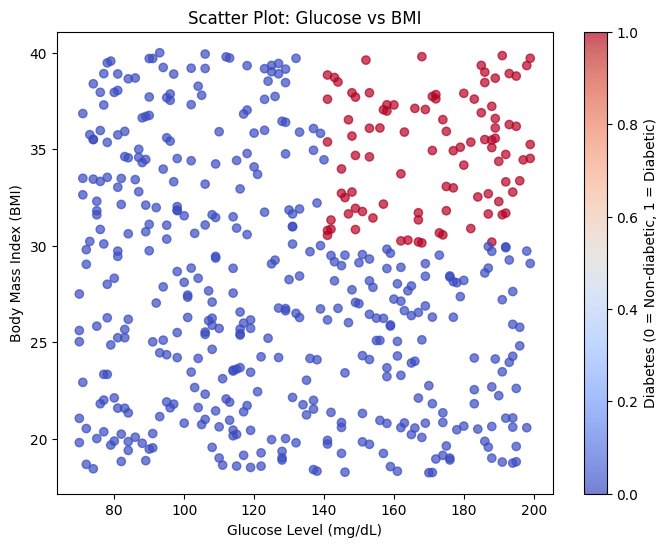

In [55]:
# Scatter Plot: Glucose vs BMI
plt.figure(figsize=(8, 6))
plt.scatter(df['Glucose'], df['BMI'], c=df['Diabetes'], cmap='coolwarm', alpha=0.7)
plt.title('Scatter Plot: Glucose vs BMI')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Body Mass Index (BMI)')
plt.colorbar(label='Diabetes (0 = Non-diabetic, 1 = Diabetic)')
plt.show()